In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split    
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
#load dataset
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
print("Features Name: ", iris.feature_names)
print("Target Name: ", iris.target_names)

Features Name:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Name:  ['setosa' 'versicolor' 'virginica']


In [5]:
#divede data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train.shape,y_train.shape

((120, 4), (120,))

In [7]:
y_train.shape,y_test.shape

((120,), (30,))

In [8]:
#train the model
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [9]:
#prediction
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
#confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


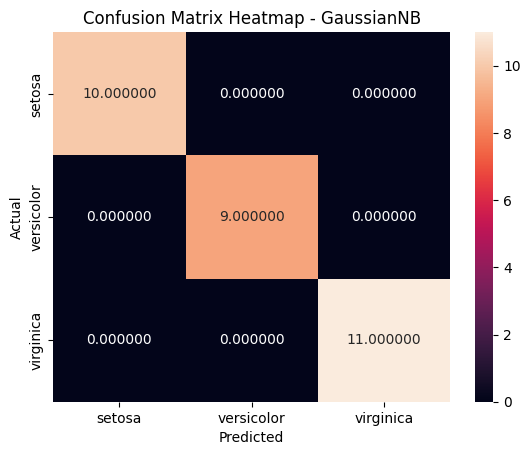

In [13]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='2f',xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - GaussianNB')
plt.show()

In [14]:
#few sample predictions
print("\nprediction probabilities(first 5 samples):\n", model.predict_proba(X_test[:5]))


prediction probabilities(first 5 samples):
 [[5.97327448e-090 9.95635767e-001 4.36423302e-003]
 [1.00000000e+000 4.96158126e-014 6.54922363e-021]
 [7.31890302e-290 4.92947614e-012 1.00000000e+000]
 [2.81842533e-094 9.77593559e-001 2.24064412e-002]
 [1.13877801e-105 8.70022596e-001 1.29977404e-001]]


In [15]:
import pandas as pd
prob_df = pd.DataFrame(model.predict_proba(X_test[:5]), columns=iris.target_names)
print("\nPrediction Probabilities DataFrame:\n", prob_df)   
print("\nProbabilities for the first sample:\n", prob_df.iloc[0])


Prediction Probabilities DataFrame:
           setosa    versicolor     virginica
0   5.973274e-90  9.956358e-01  4.364233e-03
1   1.000000e+00  4.961581e-14  6.549224e-21
2  7.318903e-290  4.929476e-12  1.000000e+00
3   2.818425e-94  9.775936e-01  2.240644e-02
4  1.138778e-105  8.700226e-01  1.299774e-01

Probabilities for the first sample:
 setosa        5.973274e-90
versicolor    9.956358e-01
virginica     4.364233e-03
Name: 0, dtype: float64
